# H1 - Selectivite accrue des IPOs 2022-2024 vs 2019-2021

## Problematique
Verifier si les IPOs 2022-2024 presentent :
- un chiffre d'affaires median plus eleve,
- une part d'entreprises rentables plus elevee,
par rapport a 2019-2021.

## Methodologie
1. Statistiques descriptives comparatives
2. IC 95 % : bootstrap (mediane CA) et Wilson (proportion rentable)
3. Mann-Whitney U unilateral (CA)
4. Z-test unilateral des proportions (rentabilite)
5. Regression OLS multivariee de controle

## Donnee d'entree
- data/dataset_complet_filled.xlsx

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 110})

COLORS = {'c1': '#2C7BB6', 'c2': '#D7191C'}
SEED = 42
np.random.seed(SEED)

print('Imports OK')

Imports OK


In [2]:
DATA_PATH = 'data/dataset_complet_filled.xlsx'
df_raw = pd.read_excel(DATA_PATH)

print(f'Fichier charge: {DATA_PATH}')
print(f'Lignes: {len(df_raw):,}'.replace(',', ' '))
print('Colonnes disponibles:')
print(df_raw.columns.tolist())

def pick_column(cols, candidates):
    lower_map = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def pick_contains(cols, keywords):
    for c in cols:
        c_low = c.lower()
        if all(k in c_low for k in keywords):
            return c
    return None

cols = list(df_raw.columns)

col_year = pick_column(cols, ['year', 'ipo_year', 'annee', 'annee_ipo']) or pick_contains(cols, ['year'])
col_rev = pick_column(cols, ['revenue_ltm', 'ltm_revenue', 'revenue', 'ca_ltm', 'chiffre_affaires']) or pick_contains(cols, ['revenue'])
col_prof = pick_column(cols, ['profitable', 'profitability', 'net_income_ltm_positive', 'rentable', 'is_profitable']) or pick_contains(cols, ['profit'])
col_size = pick_column(cols, ['ipo_size_m', 'offer_size_m', 'deal_size_m', 'size_m', 'ipo_size'])
col_under = pick_column(cols, ['underpricing', 'initial_return', 'ret_1d', 'first_day_return'])
col_sector = pick_column(cols, ['sector', 'industry', 'gics_sector'])

if col_year is None or col_rev is None or col_prof is None:
    raise ValueError(
        'Colonnes essentielles non detectees automatiquement. '
        f'year={col_year}, revenue={col_rev}, profitable={col_prof}. '
        'Adaptez la cellule de mapping.'
    )

print('\nMapping detecte:')
print(f'- year -> {col_year}')
print(f'- revenue_ltm -> {col_rev}')
print(f'- profitable -> {col_prof}')
print(f'- ipo_size_m -> {col_size}')
print(f'- underpricing -> {col_under}')
print(f'- sector -> {col_sector}')

work = pd.DataFrame({
    'year': pd.to_numeric(df_raw[col_year], errors='coerce'),
    'revenue_ltm': pd.to_numeric(df_raw[col_rev], errors='coerce')
})

prof_src = df_raw[col_prof]
if pd.api.types.is_bool_dtype(prof_src):
    work['profitable'] = prof_src.astype(float)
elif pd.api.types.is_numeric_dtype(prof_src):
    work['profitable'] = (pd.to_numeric(prof_src, errors='coerce') > 0).astype(float)
else:
    txt = prof_src.astype(str).str.strip().str.lower()
    pos = {'1', 'true', 'yes', 'y', 'oui', 'rentable', 'profitable', 'positive'}
    neg = {'0', 'false', 'no', 'n', 'non', 'unprofitable', 'negative'}
    work['profitable'] = np.where(txt.isin(pos), 1.0, np.where(txt.isin(neg), 0.0, np.nan))

if col_size is not None:
    work['ipo_size_m'] = pd.to_numeric(df_raw[col_size], errors='coerce')
else:
    work['ipo_size_m'] = np.nan

if col_under is not None:
    work['underpricing'] = pd.to_numeric(df_raw[col_under], errors='coerce')
else:
    work['underpricing'] = np.nan

if col_sector is not None:
    work['sector'] = df_raw[col_sector].astype(str)
else:
    work['sector'] = 'Unknown'

work = work[work['year'].between(2019, 2024)].copy()
if work['ipo_size_m'].notna().any():
    work = work[(work['ipo_size_m'].isna()) | (work['ipo_size_m'] >= 50)].copy()

work['cohort_period'] = np.where(work['year'].between(2019, 2021), '2019-2021', '2022-2024')
work = work[work['cohort_period'].isin(['2019-2021', '2022-2024'])].copy()

work_rev = work.dropna(subset=['revenue_ltm']).copy()
work_prof = work.dropna(subset=['profitable']).copy()

a = work_rev[work_rev['cohort_period'] == '2019-2021']['revenue_ltm'].to_numpy()
b = work_rev[work_rev['cohort_period'] == '2022-2024']['revenue_ltm'].to_numpy()
p1 = work_prof[work_prof['cohort_period'] == '2019-2021']['profitable'].to_numpy()
p2 = work_prof[work_prof['cohort_period'] == '2022-2024']['profitable'].to_numpy()

print('\nEffectifs apres preparation:')
print(work['cohort_period'].value_counts())
print(f'Revenus non manquants: 2019-2021={len(a)} | 2022-2024={len(b)}')
print(f'Rentabilite non manquante: 2019-2021={len(p1)} | 2022-2024={len(p2)}')

Fichier charge: data/dataset_complet_filled.xlsx
Lignes: 782
Colonnes disponibles:
['ticker', 'year', 'ipo_date', 'open_px', 'close_px', 'underpricing', 'ret_30d', 'ret_12m', 'ipo_size_m', 'fed_rate', 'sic', 'sector', 'pe_backed', 'cohort', 'cohort_en', 'log_size', 'company_age', 'revenue_ltm', 'profitable']

Mapping detecte:
- year -> year
- revenue_ltm -> revenue_ltm
- profitable -> profitable
- ipo_size_m -> ipo_size_m
- underpricing -> underpricing
- sector -> sector

Effectifs apres preparation:
cohort_period
2019-2021    237
2022-2024     84
Name: count, dtype: int64
Revenus non manquants: 2019-2021=208 | 2022-2024=83
Rentabilite non manquante: 2019-2021=237 | 2022-2024=84


In [3]:
def describe_group(df_rev, df_prof, label):
    rev = df_rev[df_rev['cohort_period'] == label]['revenue_ltm'].dropna()
    prof = df_prof[df_prof['cohort_period'] == label]['profitable'].dropna()
    return {
        'Cohorte': label,
        'N IPOs (base)': int((work['cohort_period'] == label).sum()),
        'N revenu': int(len(rev)),
        'CA median (M$)': float(np.median(rev)) if len(rev) else np.nan,
        'CA moyen (M$)': float(np.mean(rev)) if len(rev) else np.nan,
        'CA ecart-type (M$)': float(np.std(rev, ddof=1)) if len(rev) > 1 else np.nan,
        'N profitable': int(np.nansum(prof)) if len(prof) else 0,
        '% rentables': float(np.mean(prof) * 100) if len(prof) else np.nan
    }

summary = pd.DataFrame([
    describe_group(work_rev, work_prof, '2019-2021'),
    describe_group(work_rev, work_prof, '2022-2024')
])
summary

,Cohorte,N IPOs (base),N revenu,CA median (M$),CA moyen (M$),CA ecart-type (M$),N profitable,% rentables
0,2019-2021,237,208,163.238,1143.057276,4644.540666,56,23.628692
1,2022-2024,84,83,348.162,28189.137807,232527.777978,43,51.190476


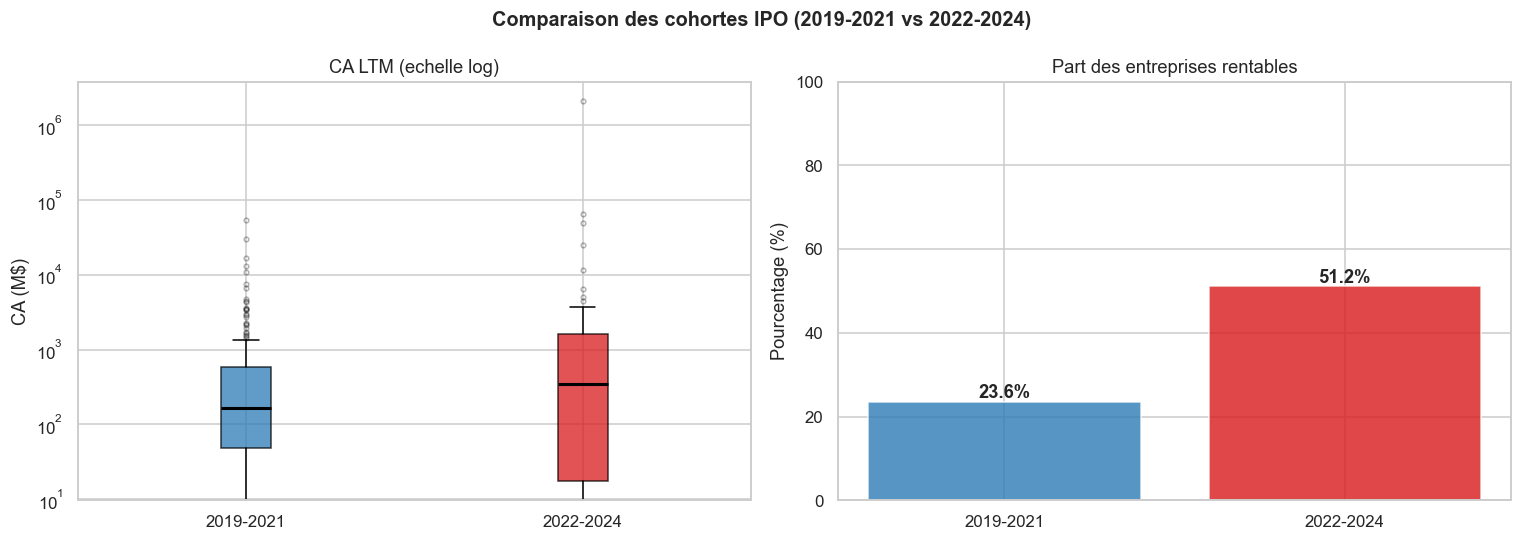

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison des cohortes IPO (2019-2021 vs 2022-2024)', fontsize=13, fontweight='bold')

if len(a) > 0 and len(b) > 0:
    bp = axes[0].boxplot(
        [a, b],
        labels=['2019-2021', '2022-2024'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor(COLORS['c1'])
    bp['boxes'][1].set_facecolor(COLORS['c2'])
    bp['boxes'][0].set_alpha(0.75)
    bp['boxes'][1].set_alpha(0.75)
    axes[0].set_yscale('log')
    axes[0].set_title('CA LTM (echelle log)')
    axes[0].set_ylabel('CA (M$)')
else:
    axes[0].text(0.5, 0.5, 'Donnees insuffisantes pour le CA', ha='center', va='center')
    axes[0].axis('off')

r1 = np.mean(p1) * 100 if len(p1) else np.nan
r2 = np.mean(p2) * 100 if len(p2) else np.nan
bars = axes[1].bar(['2019-2021', '2022-2024'], [r1, r2], color=[COLORS['c1'], COLORS['c2']], alpha=0.8)
for bar, val in zip(bars, [r1, r2]):
    if np.isfinite(val):
        axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.8, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Part des entreprises rentables')
axes[1].set_ylabel('Pourcentage (%)')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [5]:
def median_ci_bootstrap(data, n_boot=5000, alpha=0.05, seed=42):
    data = np.asarray(data)
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = np.array([
        np.median(rng.choice(data, size=len(data), replace=True))
        for _ in range(n_boot)
    ])
    med = float(np.median(data))
    lo, hi = np.quantile(boots, [alpha / 2, 1 - alpha / 2])
    return med, float(lo), float(hi)

med1, med1_lo, med1_hi = median_ci_bootstrap(a, n_boot=5000, seed=SEED)
med2, med2_lo, med2_hi = median_ci_bootstrap(b, n_boot=5000, seed=SEED + 1)

k1 = int(np.nansum(p1)) if len(p1) else 0
k2 = int(np.nansum(p2)) if len(p2) else 0
n1 = int(len(p1))
n2 = int(len(p2))

if n1 > 0:
    p1_lo, p1_hi = proportion_confint(k1, n1, alpha=0.05, method='wilson')
else:
    p1_lo, p1_hi = np.nan, np.nan

if n2 > 0:
    p2_lo, p2_hi = proportion_confint(k2, n2, alpha=0.05, method='wilson')
else:
    p2_lo, p2_hi = np.nan, np.nan

print('=== IC 95 % : Mediane CA LTM (bootstrap) ===')
print(f'2019-2021 : {med1:,.1f} M$ | [{med1_lo:,.1f} ; {med1_hi:,.1f}]'.replace(',', ' '))
print(f'2022-2024 : {med2:,.1f} M$ | [{med2_lo:,.1f} ; {med2_hi:,.1f}]'.replace(',', ' '))

print('\n=== IC 95 % : Part rentables (Wilson) ===')
if n1 > 0:
    print(f'2019-2021 : {k1/n1:.2%} | [{p1_lo:.2%} ; {p1_hi:.2%}]')
else:
    print('2019-2021 : donnees insuffisantes')

if n2 > 0:
    print(f'2022-2024 : {k2/n2:.2%} | [{p2_lo:.2%} ; {p2_hi:.2%}]')
else:
    print('2022-2024 : donnees insuffisantes')

=== IC 95 % : Mediane CA LTM (bootstrap) ===
2019-2021 : 163.2 M$ | [140.5 ; 225.4]
2022-2024 : 348.2 M$ | [171.2 ; 722.4]

=== IC 95 % : Part rentables (Wilson) ===
2019-2021 : 23.63% | [18.67% ; 29.43%]
2022-2024 : 51.19% | [40.69% ; 61.59%]


In [6]:
alpha = 0.05

print('=== Mann-Whitney U (H1: CA 2022-2024 > 2019-2021) ===')
if len(a) > 0 and len(b) > 0:
    u_stat, p_mw = stats.mannwhitneyu(b, a, alternative='greater')
    print(f'U = {u_stat:.0f} | p-value = {p_mw:.6f}')
    if p_mw < alpha:
        print('Conclusion: CA significativement plus eleve en 2022-2024.')
    else:
        print('Conclusion: pas de preuve suffisante sur le CA.')
else:
    p_mw = np.nan
    print('Donnees insuffisantes pour Mann-Whitney.')

print('\n=== Z-test proportion rentable (H1: 2022-2024 > 2019-2021) ===')
if n1 > 0 and n2 > 0:
    z_stat, p_z = proportions_ztest(count=np.array([k2, k1]), nobs=np.array([n2, n1]), alternative='larger')
    print(f'Z = {z_stat:.4f} | p-value = {p_z:.6f}')
    if p_z < alpha:
        print('Conclusion: part rentable significativement plus elevee en 2022-2024.')
    else:
        print('Conclusion: pas de preuve suffisante sur la proportion rentable.')
else:
    p_z = np.nan
    print('Donnees insuffisantes pour le Z-test.')

pd.DataFrame({
    'Test': ['Mann-Whitney CA', 'Z-test proportion rentable'],
    'p-value': [p_mw, p_z],
    'Significatif a 5%': [bool(p_mw < alpha) if np.isfinite(p_mw) else np.nan,
                           bool(p_z < alpha) if np.isfinite(p_z) else np.nan]
})

=== Mann-Whitney U (H1: CA 2022-2024 > 2019-2021) ===
U = 9699 | p-value = 0.049929
Conclusion: CA significativement plus eleve en 2022-2024.

=== Z-test proportion rentable (H1: 2022-2024 > 2019-2021) ===
Z = 4.6998 | p-value = 0.000001
Conclusion: part rentable significativement plus elevee en 2022-2024.


,Test,p-value,Significatif a 5%
0,Mann-Whitney CA,0.049929,True
1,Z-test proportion rentable,0.000001,True


In [7]:
# OLS de controle
# underpricing ~ cohorte + log(revenue) + rentable + log(size) + effets secteur

df_ols = work.copy()
df_ols['is_post_2021'] = (df_ols['cohort_period'] == '2022-2024').astype(int)
df_ols['log_rev'] = np.log1p(df_ols['revenue_ltm'].clip(lower=0))
df_ols['log_size'] = np.log1p(df_ols['ipo_size_m'].clip(lower=0)) if df_ols['ipo_size_m'].notna().any() else np.nan

if df_ols['underpricing'].notna().sum() < 30:
    print('Underpricing absent ou insuffisant: OLS non estimee.')
    ols_ok = False
else:
    ols_ok = True
    x_cols = ['is_post_2021', 'log_rev', 'profitable']
    if df_ols['log_size'].notna().sum() >= 30:
        x_cols.append('log_size')

    dummies = pd.get_dummies(df_ols['sector'], prefix='sec', drop_first=True)
    X = pd.concat([df_ols[x_cols], dummies], axis=1)
    y = df_ols['underpricing']

    mat = pd.concat([y, X], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    y_clean = mat['underpricing']
    X_clean = sm.add_constant(mat.drop(columns=['underpricing']).astype(float))

    model = sm.OLS(y_clean, X_clean).fit(cov_type='HC3')
    print(model.summary())

print('\n=== Synthese finale H1 ===')
print('- H1a (CA median plus eleve en 2022-2024):', 'CONFIRMEE' if (np.isfinite(p_mw) and p_mw < 0.05) else 'NON CONFIRMEE')
print('- H1b (part rentable plus elevee en 2022-2024):', 'CONFIRMEE' if (np.isfinite(p_z) and p_z < 0.05) else 'NON CONFIRMEE')

if ols_ok:
    coef = model.params.get('is_post_2021', np.nan)
    pcoef = model.pvalues.get('is_post_2021', np.nan)
    print(f'- OLS controle: coef is_post_2021 = {coef:.4f}, p-value = {pcoef:.4f}')
    if np.isfinite(pcoef):
        if pcoef < 0.05:
            print('  -> Effet de cohorte significatif apres controle.')
        else:
            print('  -> Effet de cohorte non significatif apres controle.')

synthese = pd.DataFrame({
    'Indicateur': [
        'CA median LTM (M$)',
        'Part rentable (%)',
        'p-value Mann-Whitney',
        'p-value Z-test'
    ],
    '2019-2021': [
        med1,
        (k1 / n1 * 100) if n1 > 0 else np.nan,
        np.nan,
        np.nan
    ],
    '2022-2024': [
        med2,
        (k2 / n2 * 100) if n2 > 0 else np.nan,
        np.nan,
        np.nan
    ],
    'Valeur': [np.nan, np.nan, p_mw, p_z]
})

synthese

                            OLS Regression Results                            
Dep. Variable:           underpricing   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.019
Method:                 Least Squares   F-statistic:                     1.074
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.382
Time:                        13:50:47   Log-Likelihood:                 52.337
No. Observations:                 291   AIC:                            -84.67
Df Residuals:                     281   BIC:                            -47.94
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1880      0.137     

,Indicateur,2019-2021,2022-2024,Valeur
0,CA median LTM (M$),163.238000,348.162000,NaN
1,Part rentable (%),23.628692,51.190476,NaN
2,p-value Mann-Whitney,NaN,NaN,0.049929
3,p-value Z-test,NaN,NaN,0.000001
